In [2]:
import polars as pl
import ast
import numpy as np
import matplotlib.pyplot as plt
from procompa import get_project_root

PRJ_ROOT = get_project_root()
data_dir = PRJ_ROOT / "data"

Total complexes: 613
Has output — p70: 511  p80: 524
Lost in p70 (p80>0, p70=0): 14
Gained in p70 (p70>0, p80=0): 1
n_assemblies changed: 73

Confidence diff (70-80): mean=-0.354  median=0.000


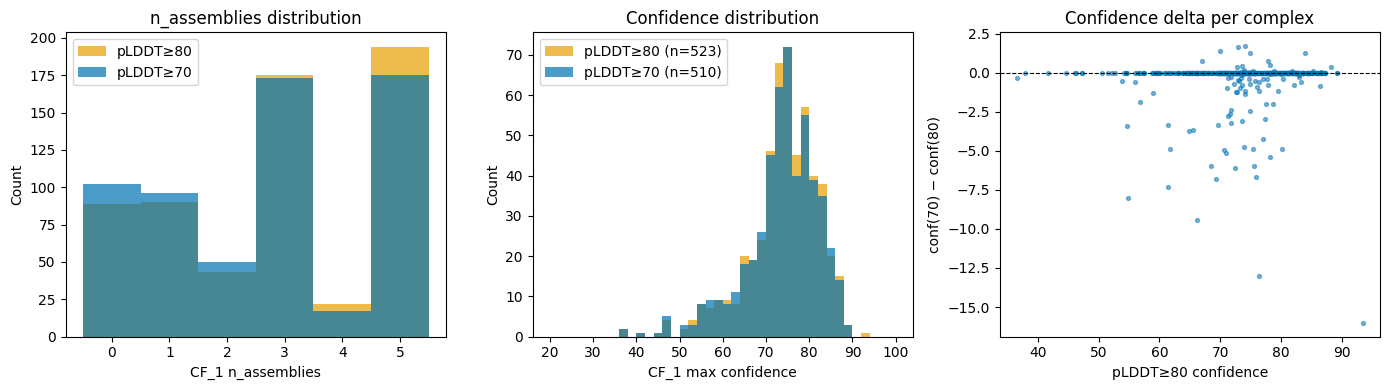

In [3]:

P70 = data_dir / "Pipeline/13_all_CP_complexes_plddt_70_threshold/all_pdb_present_13_CP_complexes_plddt_70_threshold_pool_pipeline_complexes_combfold_results.csv"
P80 = data_dir / "Pipeline/10_all_CP_complexes/all_pdb_present_10_all_CP_complexes_pool_pipeline_complexes_combfold_results.csv"

def parse_max_conf(s):
    if not s or s == "{}":
        return None
    try:
        return max(ast.literal_eval(s).values())
    except:
        return None

def load(path, suffix):
    return (
        pl.read_csv(path)
        .with_columns([
            pl.col("CF_1_n_assemblies").cast(pl.Int32, strict=False),
            pl.col("CF_1_confidence").map_elements(parse_max_conf, return_dtype=pl.Float64).alias("cf1_max_conf"),
        ])
        .select(["complex_ac", "CF_1_n_assemblies", "cf1_max_conf"])
        .rename({"CF_1_n_assemblies": f"n_{suffix}", "cf1_max_conf": f"conf_{suffix}"})
    )

m = load(P70, "70").join(load(P80, "80"), on="complex_ac")

# --- summary ---
print(f"Total complexes: {len(m)}")
print(f"Has output — p70: {(m['n_70'] > 0).sum()}  p80: {(m['n_80'] > 0).sum()}")
print(f"Lost in p70 (p80>0, p70=0): {((m['n_80'] > 0) & (m['n_70'] == 0)).sum()}")
print(f"Gained in p70 (p70>0, p80=0): {((m['n_70'] > 0) & (m['n_80'] == 0)).sum()}")
print(f"n_assemblies changed: {(m['n_70'] != m['n_80']).sum()}")
paired = m.filter(pl.col("conf_70").is_not_null() & pl.col("conf_80").is_not_null()) \
          .with_columns((pl.col("conf_70") - pl.col("conf_80")).alias("conf_diff"))
print(f"\nConfidence diff (70-80): mean={paired['conf_diff'].mean():.3f}  median={paired['conf_diff'].median():.3f}")

# --- plots ---
BLUE, ORANGE = '#0072B2', '#E69F00'
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# n_assemblies histogram
ax = axes[0]
bins = np.arange(-0.5, 6.5)
ax.hist(m["n_80"].drop_nulls().to_numpy(), bins=bins, alpha=0.7, color=ORANGE, label="pLDDT≥80")
ax.hist(m["n_70"].drop_nulls().to_numpy(), bins=bins, alpha=0.7, color=BLUE,   label="pLDDT≥70")
ax.set(xlabel="CF_1 n_assemblies", ylabel="Count", title="n_assemblies distribution")
ax.legend()

# confidence histogram
ax = axes[1]
bins = np.linspace(20, 100, 41)
ax.hist(m["conf_80"].drop_nulls().to_numpy(), bins=bins, alpha=0.7, color=ORANGE, label=f"pLDDT≥80 (n={m['conf_80'].drop_nulls().__len__()})")
ax.hist(m["conf_70"].drop_nulls().to_numpy(), bins=bins, alpha=0.7, color=BLUE,   label=f"pLDDT≥70 (n={m['conf_70'].drop_nulls().__len__()})")
ax.set(xlabel="CF_1 max confidence", ylabel="Count", title="Confidence distribution")
ax.legend()

# confidence diff scatter
ax = axes[2]
x = paired["conf_80"].to_numpy()
y = paired["conf_diff"].to_numpy()
ax.scatter(x, y, s=8, alpha=0.5, color=BLUE)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set(xlabel="pLDDT≥80 confidence", ylabel="conf(70) − conf(80)", title="Confidence delta per complex")

plt.tight_layout()
plt.show()